In [1]:
import numpy as np

In [2]:
def init_params(m, n, data_dim):
    dim = (m, n, data_dim)
    grid = np.random.randn(*dim)
    return grid

def decay(param, iter, T, decay_method='lin'):
    if decay_method == 'lin':
        return param * (1 - (iter / T))
    else:
        return param * np.exp(-(iter / T))

def decay_params(alpha_0, sigma_0, iter, T, decay_method='exp'):
    alpha_decayed, sigma_decayed = decay(np.array([alpha_0, sigma_0]), iter, T)
    return alpha_decayed, sigma_decayed

def get_bmu_idx(weights, instance):
    dist = np.linalg.norm(weights - instance, axis=-1)
    return np.unravel_index(np.argmin(dist), dist.shape)


def neighbor_func(bmu_idx, m, n, sigma_decayed):
    I, J = np.indices((m, n))
    u_c, v_c = bmu_idx
    dist_sq = (I - u_c)**2 + (J - v_c)**2

    h_ci = np.exp(- dist_sq / (2 * sigma_decayed**2))
    return h_ci

def update_weights(grid, alpha_decayed, h_ci, x):
    h_ci_expanded = h_ci[:, :, np.newaxis]
    grid += alpha_decayed * h_ci_expanded * (x - grid)

def som_train(x_train, m, n, alpha_0, sigma_0, T):
    data_dim = x_train.shape[1]
    grid = init_params(m, n, data_dim)

    for iter in range(T):
        alpha_decayed, sigma_decayed = decay_params(alpha_0, sigma_0, iter, T, decay_method='exp')
        
        for x in x_train:
            bmu_idx = get_bmu_idx(grid, x)
            h_ci = neighbor_func(bmu_idx, m, n, sigma_decayed)
            update_weights(grid, alpha_decayed, h_ci, x)

    return grid

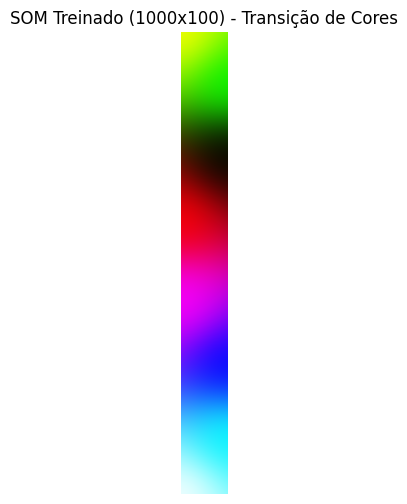

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1.0, 1.0, 0.0],
    [0.0, 1.0, 1.0],
    [1.0, 0.0, 1.0],
    [0.0, 0.0, 0.0],
    [1.0, 1.0, 1.0],
])

m, n = 1000, 100
alpha_0 = 0.8
sigma_0 = max(m, n) / 2
T = 100

grid_treinada = som_train(x_train, m, n, alpha_0, sigma_0, T)

grid_plot = np.clip(grid_treinada, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(grid_plot)
plt.title(f"SOM Treinado ({m}x{n}) - Transição de Cores")
plt.axis('off')
plt.show()